Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("E:/chun_project/data/telco.csv")
print("Shape",df.shape)
df.head()

Shape (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Drop Data Leakage Columns

In [5]:
cols_to_drop=[ "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"]
df.drop(columns=cols_to_drop,inplace=True)

Check New Shape

In [6]:
df.head()
df.shape

(7043, 20)

Check Churn Distribution

In [7]:
df["Churn Value"].value_counts()


Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [8]:
df["Churn Value"].value_counts(normalize=True)*100
#normalize=True: Instead of returning the raw count (e.g., 500 people), 
# it returns the relative frequency or proportion

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Feature Types

In [9]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
cat_cols=df.select_dtypes(include=["object"]).columns

print("Numerical columns:",num_cols)
print("Categorical Columns:",cat_cols)

Numerical columns: Index(['Tenure Months', 'Monthly Charges', 'Churn Value'], dtype='object')
Categorical Columns: Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='object')


In [10]:
df["Total Charges"].head()
df["Total Charges"].dtype

dtype('O')

Fix Total Charges object to numeric

In [11]:
df["Total Charges"]=pd.to_numeric(df["Total Charges"],errors="coerce")

Check Missing Values

In [12]:
df["Total Charges"].isnull().sum()

11

In [13]:
#dropping NaN 
df.dropna(inplace=True)

In [14]:
df.isnull().sum().sum
df.shape



(7032, 20)

Separate Features and Target

In [15]:
X=df.drop("Churn Value", axis=1)
y=df["Churn Value"]

print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (7032, 19)
y shape: (7032,)


Train/Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("X train shape:",X_train.shape)
print("X test shape:",X_test.shape)

X train shape: (5625, 19)
X test shape: (1407, 19)


Encoding

In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical & numerical columns
cat_cols=X_train.select_dtypes(include="object").columns
num_cols=X_train.select_dtypes(include=["int64","float64"]).columns

print("Categorical:", len(cat_cols))
print("Numerical:",len(num_cols))



Categorical: 16
Numerical: 3


In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

#Define columntransformer
preprocessor=ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(drop="first",handle_unknown="ignore"),cat_cols),
        ("num","passthrough",num_cols)
    ]
)

Model building

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model=Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train,y_train)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Tenure Months', 'Monthly Charges', 'Total Charges'], dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [20]:
from sklearn.metrics import classification_report
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.65      0.61      0.63       374

    accuracy                           0.81      1407
   macro avg       0.75      0.74      0.75      1407
weighted avg       0.80      0.81      0.81      1407



Non-Churn (Class 0)
Churn (Class 1)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model=Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("classifier",RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Modify Logistic With Class Weight

In [22]:

from sklearn.linear_model import LogisticRegression
model_balanced=Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("classifier",LogisticRegression(max_iter=1000,class_weight="balanced"))
])
model_balanced.fit(X_train,y_train)

y_pred_bal=model_balanced.predict(X_test)

print(classification_report(y_test,y_pred_bal))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC-AUC comparison

In [23]:
from sklearn.metrics import roc_auc_score

y_proba=model_balanced.predict_proba(X_test)[:,1]
roc_auc_score(y_test,y_proba)

0.8430962722147735

probability distribution

In [24]:
import numpy as np
y_proba=model_balanced.predict_proba(X_test)[:,1]

np.percentile(y_proba,[10,25,50,75,90])

array([0.02178123, 0.08866661, 0.40136543, 0.73405679, 0.84842832])

In [25]:
from sklearn.metrics import classification_report

# Try threshold = 0.4
threshold = 0.4
y_pred_custom = (y_proba >= threshold).astype(int)

print("Threshold:", threshold)
print(classification_report(y_test, y_pred_custom))

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1033
           1       0.46      0.87      0.60       374

    accuracy                           0.70      1407
   macro avg       0.70      0.75      0.68      1407
weighted avg       0.81      0.70      0.71      1407



In [26]:
threshold = 0.6
y_pred_custom = (y_proba >= threshold).astype(int)

print("Threshold:", threshold)
print(classification_report(y_test, y_pred_custom))

Threshold: 0.6
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1033
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



Extract Feature Names After Encoding

In [27]:
# Get feature names after encoding
encoded_feature_names = model_balanced.named_steps["preprocessing"].get_feature_names_out()

# Get coefficients
coefficients = model_balanced.named_steps["classifier"].coef_[0]

# Create dataframe
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Coefficient": coefficients
})

feature_importance["Abs_Coeff"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values(by="Abs_Coeff", ascending=False)

feature_importance.head(15)

,Feature,Coefficient,Abs_Coeff
3,cat__Dependents_Yes,-1.630679,1.630679
22,cat__Contract_Two year,-1.439476,1.439476
21,cat__Contract_One year,-0.851114,0.851114
5,cat__Multiple Lines_No phone service,0.601304,0.601304
16,cat__Tech Support_Yes,-0.470719,0.470719
10,cat__Online Security_Yes,-0.465981,0.465981
25,cat__Payment Method_Electronic check,0.416069,0.416069
4,cat__Phone Service_Yes,-0.318738,0.318738
7,cat__Internet Service_Fiber optic,0.274110,0.274110
12,cat__Online Backup_Yes,-0.248279,0.248279


model says:

##Stable customers:
Have dependents
Long contracts
Use tech support
Use security services

##Risky customers:

Month-to-month
Electronic check payment
Fiber optic only
Low service bundling

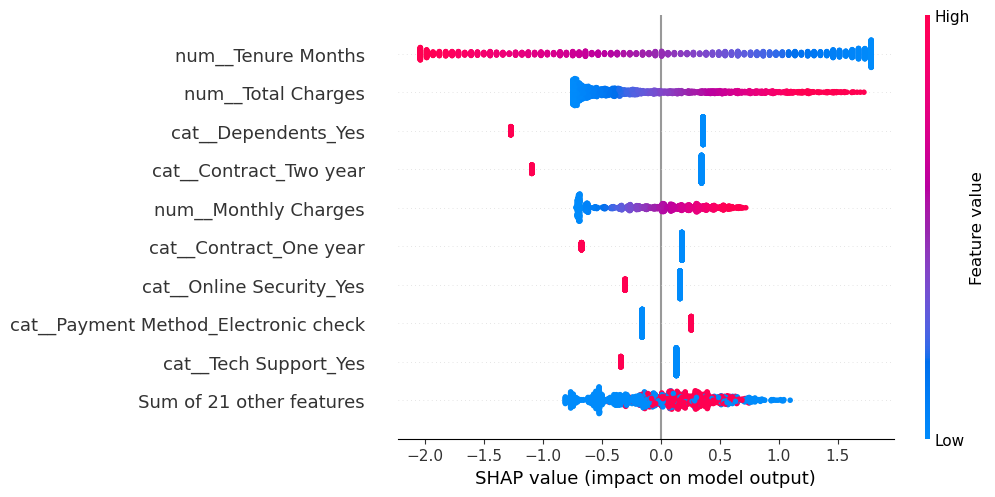

In [28]:
import shap
import pandas as pd

# Get processed feature names
feature_names = model_balanced.named_steps["preprocessing"].get_feature_names_out()

# Transform training & test data
X_train_processed = model_balanced.named_steps["preprocessing"].transform(X_train)
X_test_processed = model_balanced.named_steps["preprocessing"].transform(X_test)

# Convert to DataFrame
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

# Create SHAP explainer
explainer = shap.Explainer(
    model_balanced.named_steps["classifier"],
    X_train_df
)

# Get SHAP values
shap_values = explainer(X_test_df)

# Summary plot
shap.plots.beeswarm(shap_values)

In [31]:
FINAL_THRESHOLD = 0.45

In [32]:
import joblib

joblib.dump(model_balanced, "churn_model.pkl")

['churn_model.pkl']